# 8 &middot; Contact: a Ball Pushing into a Soft Block

Contact is just another **energy**: a penalty spring that switches on wherever a vertex pokes inside an obstacle, measured by the obstacle's signed distance $\phi$ (negative = inside). We first probe that energy on frozen shapes (a ghost ball sweeping through a block, a rigid ball sinking into the ground), then simulate a hanging block pushed by a scripted ball, once with a soft penalty and once with a 10&times; stiffer one.

$$
E_{\text{contact}}(x) = \frac{k}{2}\sum_{i:\,\phi(x_i)<0} m_i\,\phi(x_i)^2,
\qquad \phi_{\text{ball}}(x) = \lVert x - c\rVert - r,
\qquad \phi_{\text{ground}}(x) = y - y_{\text{ground}}
$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import igl
import simkit
import utils

NOTEBOOK = "008_contact_ball"                                      # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK)               # results/008_contact_ball/
MEDIA_DIR = "media"                                                # tracked copies for the website
# block mesh (hung so that y is in [0, HEIGHT])
NX, NY = 10, 12                           # grid resolution (vertices)
WIDTH, HEIGHT = 0.6, 0.8                  # block size
# material, gravity, time stepping
MATERIAL = "macklin-mueller-neo-hookean"  # Neo-Hookean elasticity
YM, PR = 200.0, 0.4                       # Young's modulus, Poisson ratio
RHO = 1.0                                 # density
GRAVITY = -4.0                            # vertical gravitational acceleration
K_PIN = 1e6                               # top-edge pin penalty stiffness
DT = 0.02                                 # Backward-Euler time step
NEWTON_MAX_ITER = 100                     # Newton iteration cap per time step
NEWTON_TOL = 1e-6                         # Newton step-size tolerance
# ball obstacle and its scripted path
BALL_R = 0.16                             # ball radius
BALL_X = 0.0                              # ball-center x (horizontal offset of the scripted path)
K_CONTACT = 5e4                           # soft contact stiffness (Experiments 1 and 3)
K_CONTACT_STIFF = 5e5                     # 10x stiffer contact (Experiment 4)
BALL_Y_START, BALL_Y_TOP = -0.5, 0.4      # ball-center height at the start/end and at the top of its path
N_LEG = 22                                # frames per leg of the path (up, then down)
# static ball probe (Experiment 1)
PROBE_Y_MIN, PROBE_Y_MAX = -0.5, 0.55     # ghost-ball center height range
N_PROBE = 44                              # number of probe positions
# ground probe (Experiment 2)
PROBE_BALL_R = 0.22                       # rigid probe-ball radius
PROBE_BALL_SEGMENTS = 48                  # rim vertices of the probe ball
GROUND_Y = 0.0                            # ground height
K_GROUND = 5e3                            # ground contact stiffness
GROUND_CLEARANCE = 0.2                    # starting gap between the ball's bottom and the ground
N_GROUND_LEG = 22                         # frames per leg (down, then up)
# derivative check
FD_STEP = 1e-5                            # central-difference step
FD_PERTURB = 0.01                         # random perturbation of the free vertices
SEED = 0                                  # random seed
# animation
FPS = 18                                  # video frame rate
SCENE_LIMS = ((-0.6, 0.6), (-0.7, 0.95))  # axes of the block scenes
GROUND_LIMS = ((-0.6, 0.6), (-0.45, 0.7)) # axes of the ground scene
COMPARE_LIMS = ((-0.55, 0.55), (-0.15, 0.9))  # axes of the soft-vs-stiff displacement panels

## The block, the obstacles, and the shared operators

The block is a `WIDTH` &times; `HEIGHT` libigl grid hung so that $0 \le y \le$ `HEIGHT`, with its top edge pinned. We precompute once what every energy reuses: the deformation jacobian, triangle areas, Lamé parameters, the lumped per-vertex masses `M_n` (they weight the contact springs), their per-coordinate `kron` form `M` (inertia), the gravity force, and the pin penalty. We also build the scripted ball path and the rigid probe ball for the ground test.

In [2]:
V, T = igl.triangulated_grid(NX, NY)                 # unit square, NX x NY vertices
X = (V - 0.5) * np.array([WIDTH, HEIGHT])            # centered WIDTH x HEIGHT rectangle
X[:, 1] += HEIGHT / 2                                # hang it: y in [0, HEIGHT]
n, dim = X.shape
pin_idx = np.where(X[:, 1] >= X[:, 1].max() - 1e-6)[0]   # top edge pinned

J = simkit.deformation_jacobian(X, T)
vol = simkit.volume(X, T)
mu_val, lam_val = simkit.ympr_to_lame(YM, PR)
mu = np.full((len(T), 1), mu_val)
lam = np.full((len(T), 1), lam_val)
M_n = simkit.massmatrix(X, T, rho=RHO)               # lumped per-vertex masses m_i
M = sp.sparse.kron(M_n, sp.sparse.eye(dim)).tocsc()  # the same masses per coordinate
f_g = simkit.gravity_force(X, T, a=GRAVITY, rho=RHO).reshape(-1, 1)
Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, K_PIN)

ball_path = np.concatenate([np.linspace(BALL_Y_START, BALL_Y_TOP, N_LEG),
                            np.linspace(BALL_Y_TOP, BALL_Y_START, N_LEG)])   # ball-center height per frame
c_top = np.array([BALL_X, BALL_Y_TOP])               # ball center at the top of its path

ball_X, ball_T = utils.ball_mesh_2d(radius=PROBE_BALL_R, n_segments=PROBE_BALL_SEGMENTS)
ball_M = simkit.massmatrix(ball_X, ball_T, rho=RHO)
ground_p, ground_n = np.array([0.0, GROUND_Y]), np.array([0.0, 1.0])   # ground plane: point and normal

Both meshes at rest: the block with its pinned top edge and the ball's lowest and highest scripted positions (dashed), and the probe ball at its deepest point, halfway into the ground.

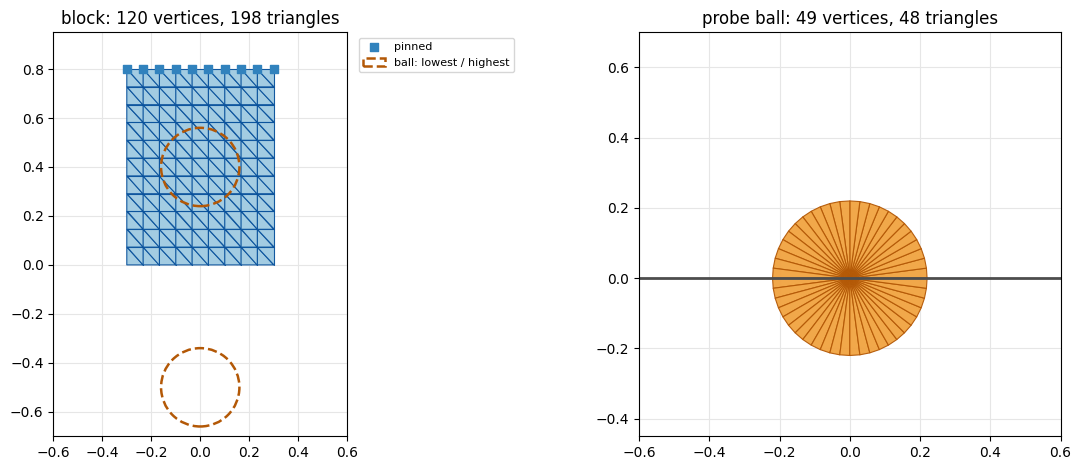

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
utils.plot_mesh(axes[0], X, T, pins=pin_idx, lims=SCENE_LIMS,
                title=f"block: {n} vertices, {len(T)} triangles")
for cy, label in ((BALL_Y_START, "ball: lowest / highest"), (BALL_Y_TOP, None)):
    axes[0].add_patch(plt.Circle((BALL_X, cy), BALL_R, fill=False, ec=utils.BALL_EDGE, ls="--", lw=1.8,
                                 zorder=6, label=label))
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8)
utils.plot_mesh(axes[1], ball_X + ground_p, ball_T, lims=GROUND_LIMS,
                facecolor=utils.BALL_FACE, edgecolor=utils.BALL_EDGE,
                title=f"probe ball: {len(ball_X)} vertices, {len(ball_T)} triangles")
axes[1].axhline(GROUND_Y, color="0.3", lw=2.0)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "meshes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "008_meshes.png"))
plt.show()

## The contact energy, vertex by vertex

With the ball frozen at the top of its path, we evaluate on the rest block the three per-vertex fields behind $E_{\text{contact}}$: the lumped mass $m_i$, the signed distance $\phi_i$, and each vertex's penalty $\tfrac{k}{2} m_i \min(\phi_i, 0)^2$, which is non-zero only inside the ball. The last two panels are on the probe ball at its deepest point: the ground's $\phi$, and the lumped masses that weight its ground penalty (the fan's center vertex carries a third of the mass, but sits exactly at $\phi = 0$, so it adds nothing). The printed lines confirm that the per-vertex penalties sum to simkit's `contact_springs_sphere_energy`, and give the center vertex's mass share and $\phi$.

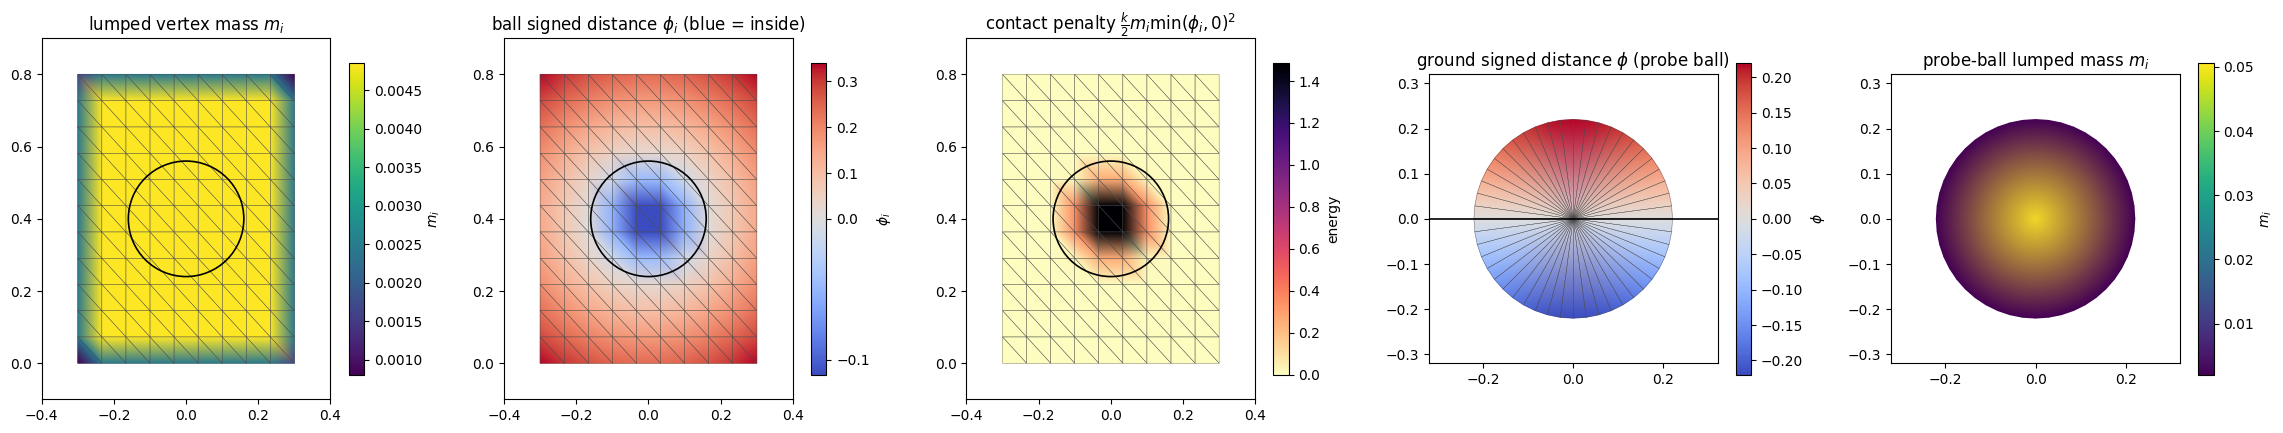

16 of 120 block vertices inside the ball;  sum of per-vertex penalties = 8.4238,  simkit contact energy = 8.4238
probe-ball center vertex: 0.333 of its mass, phi = 0.0


In [4]:
m = M_n.diagonal()
phi_ball = np.linalg.norm(X - c_top, axis=1) - BALL_R            # signed distance of every block vertex
penalty = 0.5 * K_CONTACT * m * np.minimum(phi_ball, 0.0) ** 2     # per-vertex contact energy
E_simkit = simkit.energies.contact_springs_sphere_energy(X, K_CONTACT, c_top, BALL_R, M=M_n)
ball_deep = ball_X + ground_p                                      # probe ball, center on the ground
phi_ground = (ball_deep - ground_p) @ ground_n                     # signed distance to the ground

fig, axes = plt.subplots(1, 5, figsize=(23, 4.4))
utils.plot_scalar_field(axes[0], X, T, m, title="lumped vertex mass $m_i$", label="$m_i$")
utils.plot_scalar_field(axes[1], X, T, phi_ball, cmap="coolwarm", label=r"$\phi_i$",
                        norm=TwoSlopeNorm(vmin=phi_ball.min(), vcenter=0.0, vmax=phi_ball.max()),
                        title=r"ball signed distance $\phi_i$ (blue = inside)")
utils.plot_scalar_field(axes[2], X, T, penalty, cmap="magma_r", label="energy",
                        title=r"contact penalty $\frac{k}{2} m_i \min(\phi_i,0)^2$")
utils.plot_scalar_field(axes[3], ball_deep, ball_T, phi_ground, cmap="coolwarm", label=r"$\phi$",
                        norm=TwoSlopeNorm(vmin=phi_ground.min(), vcenter=0.0, vmax=phi_ground.max()),
                        title=r"ground signed distance $\phi$ (probe ball)")
utils.plot_scalar_field(axes[4], ball_deep, ball_T, ball_M.diagonal(), edges=False,
                        title="probe-ball lumped mass $m_i$", label="$m_i$")
for ax in axes[:3]:
    ax.add_patch(plt.Circle(c_top, BALL_R, fill=False, ec="k", lw=1.2, zorder=6))
axes[3].axhline(GROUND_Y, color="k", lw=1.2, zorder=6)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "contact_fields.png"),
                              copy_to=os.path.join(MEDIA_DIR, "008_contact_fields.png"))
plt.show()
print(f"{int((phi_ball < 0).sum())} of {n} block vertices inside the ball;"
      f"  sum of per-vertex penalties = {penalty.sum():.4f},  simkit contact energy = {E_simkit:.4f}")
print(f"probe-ball center vertex: {ball_M.diagonal()[0] / ball_M.diagonal().sum():.3f} of its mass, "
      f"phi = {phi_ground[0]:.1f}")

## Experiment 1 &mdash; static probe: the block does not move

Freeze the block at rest and slide a **ghost ball** up through it, evaluating only the contact energy at each ball position: no stepping, no deformation. The background is the ball's signed distance. The energy switches on when the ball first touches the bottom edge (center at $y \approx -r$), rises steeply while the overlap grows, and plateaus once the ball is fully inside, with small wiggles as grid vertices enter and leave it.

In [5]:
probe_y = np.linspace(PROBE_Y_MIN, PROBE_Y_MAX, N_PROBE)
probe_centers = [np.array([BALL_X, cy]) for cy in probe_y]
probe_energy = np.array([simkit.energies.contact_springs_sphere_energy(X, K_CONTACT, c, BALL_R, M=M_n)
                         for c in probe_centers])

fig, anim = utils.animate_dynamics([X] * N_PROBE, T, probe_y, {"contact": probe_energy},
    lims=SCENE_LIMS, xlabel="ball height", ylabel="contact energy",
    colors=utils.ENERGY_COLORS, ball_centers=probe_centers, ball_radius=BALL_R, sdf=True,
    scene_title="STATIC block, ghost ball sweeping (background: $\\phi$)",
    title="contact energy vs ball position", fps=FPS)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "ball_probe.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "008_ball_probe.mp4"))
plt.close(fig)
utils.embed_video(video)

## Experiment 2 &mdash; ground probe: the energy grows with depth

Same idea against the **ground**: a rigid ball (a probe, not simulated) sinks until its center reaches the ground, halfway submerged, then rises back out, and we evaluate the plane-contact energy of its vertices. The background is the ground's signed distance (blue = inside). The energy climbs as more of the ball goes below the surface, peaks at the turnaround, and retraces on the way up. Sinking further would only raise it, since the penalty grows quadratically with depth.

In [6]:
top_y = GROUND_Y + PROBE_BALL_R + GROUND_CLEARANCE                 # starting ball-center height
ground_path = np.concatenate([np.linspace(top_y, GROUND_Y, N_GROUND_LEG),
                              np.linspace(GROUND_Y, top_y, N_GROUND_LEG)])
ball_states = [ball_X + np.array([0.0, cy]) for cy in ground_path]
ground_energy = np.array([simkit.energies.contact_springs_plane_energy(U, K_GROUND, ground_p, ground_n, M=ball_M)
                          for U in ball_states])
print(f"peak ground-contact energy {ground_energy.max():.3f} at ball-center y = "
      f"{ground_path[int(np.argmax(ground_energy))]:.2f}  (ground at {GROUND_Y})")

fig, anim = utils.animate_dynamics(ball_states, ball_T, np.arange(len(ball_states)),
    {"contact": ground_energy}, lims=GROUND_LIMS,
    xlabel="frame", ylabel="ground-contact energy", colors=utils.ENERGY_COLORS,
    floor_y=GROUND_Y, floor_sdf=True, mesh_face=utils.BALL_FACE, mesh_edge=utils.BALL_EDGE,
    scene_title="rigid ball sinking into the ground (blue = inside)",
    title="energy peaks at the deepest point", fps=FPS)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "ground_probe.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "008_ground_probe.mp4"))
plt.close(fig)
utils.embed_video(video)

peak ground-contact energy 3.058 at ball-center y = 0.00  (ground at 0.0)


## The block system

`block_system` is the Backward-Euler step objective of the block: Neo-Hookean elasticity, the pin penalty, gravity, the **sphere-contact** penalty and inertia, one term per line, all from simkit. Gravity is linear, so it has no Hessian term. The ball center and the two previous states `x_curr`, `x_prev` change every step, so we rebuild these cheap closures at each step; the constant operators above are shared.

In [7]:
def block_system(k_contact, ball_center, x_curr, x_prev):
    """Elastic + pin + gravity + ball contact + Backward-Euler inertia, in stacked positions x."""

    def energy_func(x):
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_gravity = -(f_g.T @ x).item()
        E_contact = simkit.energies.contact_springs_sphere_energy(x.reshape(n, dim), k_contact, ball_center, BALL_R, M=M_n)
        E_inertia = simkit.energies.kinetic_energy_be(x, x_curr, x_prev, M, DT)
        E_total = E_elastic + E_pin + E_gravity + E_contact + E_inertia
        return E_total

    def gradient_func(x):
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_gravity = -f_g
        g_contact = simkit.energies.contact_springs_sphere_gradient(x.reshape(n, dim), k_contact, ball_center, BALL_R, M=M_n)
        g_inertia = simkit.energies.kinetic_gradient_be(x, x_curr, x_prev, M, DT)
        g_total = g_elastic + g_pin + g_gravity + g_contact + g_inertia
        return g_total

    def hessian_func(x):
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL, psd=True)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_contact = simkit.energies.contact_springs_sphere_hessian(x.reshape(n, dim), k_contact, ball_center, BALL_R, M=M_n)
        H_inertia = simkit.energies.kinetic_hessian_be(M, DT)
        H_total = H_elastic + H_pin + H_contact + H_inertia
        return H_total

    return energy_func, gradient_func, hessian_func

A finite-difference check of that gradient, at a randomly perturbed block with the ball at the top of its path so the contact term is active. Every analytic entry should sit on the diagonal next to its central-difference estimate.

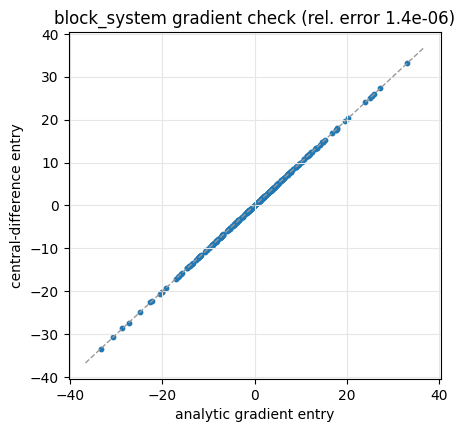

In [8]:
rng = np.random.default_rng(SEED)
free_idx = np.setdiff1d(np.arange(n), pin_idx)
X_test = X.copy()
X_test[free_idx] += FD_PERTURB * rng.standard_normal((len(free_idx), dim))
x_test = X_test.reshape(-1, 1)
x_rest = X.reshape(-1, 1)
energy_func, gradient_func, hessian_func = block_system(K_CONTACT, c_top, x_rest, x_rest)
g_analytic = gradient_func(x_test).ravel()
g_fd = simkit.gradient_cfd(lambda y: np.array(energy_func(y.reshape(-1, 1))), x_test.ravel(), FD_STEP)
rel_err = np.linalg.norm(g_fd - g_analytic) / np.linalg.norm(g_analytic)

fig, ax = plt.subplots(figsize=(4.8, 4.5))
lim = np.abs(g_analytic).max() * 1.1
ax.plot([-lim, lim], [-lim, lim], "--", color="0.6", lw=1)
ax.scatter(g_analytic, g_fd, s=10, color="#1f77b4")
ax.set_xlabel("analytic gradient entry")
ax.set_ylabel("central-difference entry")
ax.set_title(f"block_system gradient check (rel. error {rel_err:.1e})")
ax.grid(True, color="0.9", linewidth=0.8)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "gradient_check.png"),
                              copy_to=os.path.join(MEDIA_DIR, "008_gradient_check.png"))
plt.show()

`simulate` drives the scripted ball up into the block and back down. Each frame is one Backward-Euler step: rebuild `block_system` with the new ball center and history, then minimize it with Newton (line search on). It records the states, the contact energy, the deepest penetration $\max_i(-\phi_i)$ and the Newton iterations of every step.

In [9]:
def simulate(k_contact):
    """Scripted-ball run of the block with contact stiffness k_contact; one time step per frame."""
    x_curr = X.reshape(-1, 1).copy()
    x_prev = x_curr.copy()                                    # start at rest (zero velocity)
    run = {"states": [], "centers": [], "contact": [], "penetration": [], "newton_iters": []}
    for cy in ball_path:
        center = np.array([BALL_X, cy])
        energy_func, gradient_func, hessian_func = block_system(k_contact, center, x_curr, x_prev)
        x_next, info = simkit.solvers.newton_solver(x_curr, energy_func, gradient_func, hessian_func,
                                                    tolerance=NEWTON_TOL, max_iter=NEWTON_MAX_ITER,
                                                    do_line_search=True, return_info=True)
        x_prev, x_curr = x_curr, x_next
        U = x_curr.reshape(n, dim)
        phi = np.linalg.norm(U - center, axis=1) - BALL_R
        run["states"].append(U.copy())
        run["centers"].append(center)
        run["contact"].append(simkit.energies.contact_springs_sphere_energy(U, k_contact, center, BALL_R, M=M_n))
        run["penetration"].append(max(0.0, -phi.min()))
        run["newton_iters"].append(info["iters"] + 1)
    return {key: np.array(val) for key, val in run.items()}

## Experiment 3 &mdash; dynamic simulation with soft contact

Now the block responds. With $k = 5\cdot10^4$ the penalty first dents the block (the largest displacement, 0.28, is at frame 18), but it is too soft to hold the ball out: the ball then pops through the bottom edge, the block snaps back, and the ball stays embedded (penetration up to about 0.10, of a radius of 0.16) until it leaves again. The contact energy jumps when the ball pops in and stays high while it is inside.

In [10]:
soft = simulate(K_CONTACT)
disp_soft = np.linalg.norm(soft["states"] - X, axis=2)           # ||u_i|| per frame and vertex
print(f"max block displacement: {disp_soft.max():.3f} (frame {disp_soft.max(axis=1).argmax()}),  "
      f"max penetration: {soft['penetration'].max():.3f},  Newton iterations: {soft['newton_iters'].sum()}")

fig, anim = utils.animate_dynamics(list(soft["states"]), T, np.arange(len(ball_path)), {"contact": soft["contact"]},
    lims=SCENE_LIMS, xlabel="frame", ylabel="contact energy",
    colors=utils.ENERGY_COLORS, ball_centers=soft["centers"], ball_radius=BALL_R, sdf=True,
    scene_title=f"soft contact (k = {K_CONTACT:.0e}): ball tunnels in", title="contact energy", fps=FPS)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "contact_ball.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "008_contact_ball.mp4"))
plt.close(fig)
utils.embed_video(video)

max block displacement: 0.281 (frame 18),  max penetration: 0.101,  Newton iterations: 1084


## Experiment 4 &mdash; stiffer contact: the same ball, a firmer penalty

We repeat Experiment 3 exactly (same block, pins, gravity and scripted ball path) and only raise the contact stiffness 10&times; to $k = 5\cdot10^5$, by calling `simulate` again. The stiffer spring fights penetration much harder, so instead of entering the block the ball shoves it up and aside and carves a clear dent: the printed maximum displacement is 0.49 (at frame 21, the top of the path), about 1.8&times; the soft run, while the penetration stays below 0.03.

In [11]:
stiff = simulate(K_CONTACT_STIFF)
disp_stiff = np.linalg.norm(stiff["states"] - X, axis=2)         # ||u_i|| per frame and vertex
print(f"max block displacement (stiff contact): {disp_stiff.max():.3f} (frame {disp_stiff.max(axis=1).argmax()}),  "
      f"max penetration: {stiff['penetration'].max():.3f},  Newton iterations: {stiff['newton_iters'].sum()}")

fig, anim = utils.animate_dynamics(list(stiff["states"]), T, np.arange(len(ball_path)), {"contact": stiff["contact"]},
    lims=SCENE_LIMS, xlabel="frame", ylabel="contact energy",
    colors=utils.ENERGY_COLORS, ball_centers=stiff["centers"], ball_radius=BALL_R, sdf=True,
    scene_title=f"stiffer contact (k = {K_CONTACT_STIFF:.0e}): ball dents the block",
    title="contact energy (stiff)", fps=FPS)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "contact_ball_stiff.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "008_contact_ball_stiff.mp4"))
plt.close(fig)
utils.embed_video(video)

max block displacement (stiff contact): 0.494 (frame 21),  max penetration: 0.029,  Newton iterations: 771


## Soft vs stiff contact

The displacement magnitude $\lVert u_i \rVert$ of both runs at the frame where the ball is highest, on one color scale: the soft block, which has already snapped back, barely moves while the ball sits inside it, and the stiff block is pushed up and around the ball. The penalty only acts on vertices, so in the stiff run the stretched elements spanning the dent still cut across the ball (the yellow band inside the circle), even though no vertex is more than 0.03 inside it.

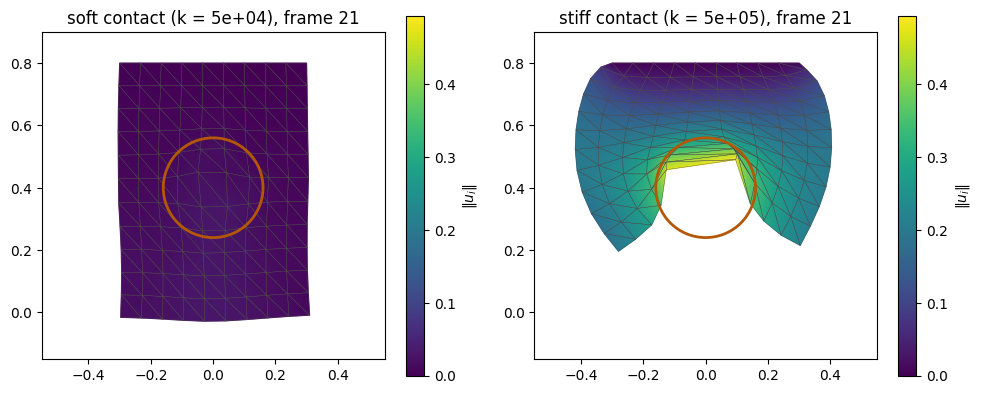

In [12]:
k_top = int(np.argmax(ball_path))                             # frame with the ball at its highest
disp = {"soft": disp_soft[k_top], "stiff": disp_stiff[k_top]}  # ||u_i|| at that frame
vmax = max(d.max() for d in disp.values())

fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
for ax, (name, run), k in zip(axes, (("soft", soft), ("stiff", stiff)), (K_CONTACT, K_CONTACT_STIFF)):
    utils.plot_scalar_field(ax, run["states"][k_top], T, disp[name], vmin=0.0, vmax=vmax, cmap="viridis",
                            lims=COMPARE_LIMS, label=r"$\|u_i\|$",
                            title=f"{name} contact (k = {k:.0e}), frame {k_top}")
    ax.add_patch(plt.Circle(run["centers"][k_top], BALL_R, fill=False, ec=utils.BALL_EDGE, lw=2, zorder=6))
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "peak_displacement.png"),
                              copy_to=os.path.join(MEDIA_DIR, "008_peak_displacement.png"))
plt.show()

Per-frame diagnostics of both runs. The stiff penalty keeps the deepest penetration about 3.5&times; smaller (left), and its contact energy peaks about 4&times; *lower* (middle) despite the 10&times; larger $k$: the energy is quadratic in $\phi$, and at each run's energy peak (printed below) the soft run, with the ball embedded, has 14 vertices inside at a mean depth of 0.044, the stiff run 11 at only 0.009. Contact is also what makes a step expensive: Newton needs 2&ndash;4 iterations per step while the ball is away from the block, and tens (up to nearly the cap) while it is in contact, most of all in the soft run, where the ball tunnels through many vertices (1084 iterations in total, against 771 for the stiff run).

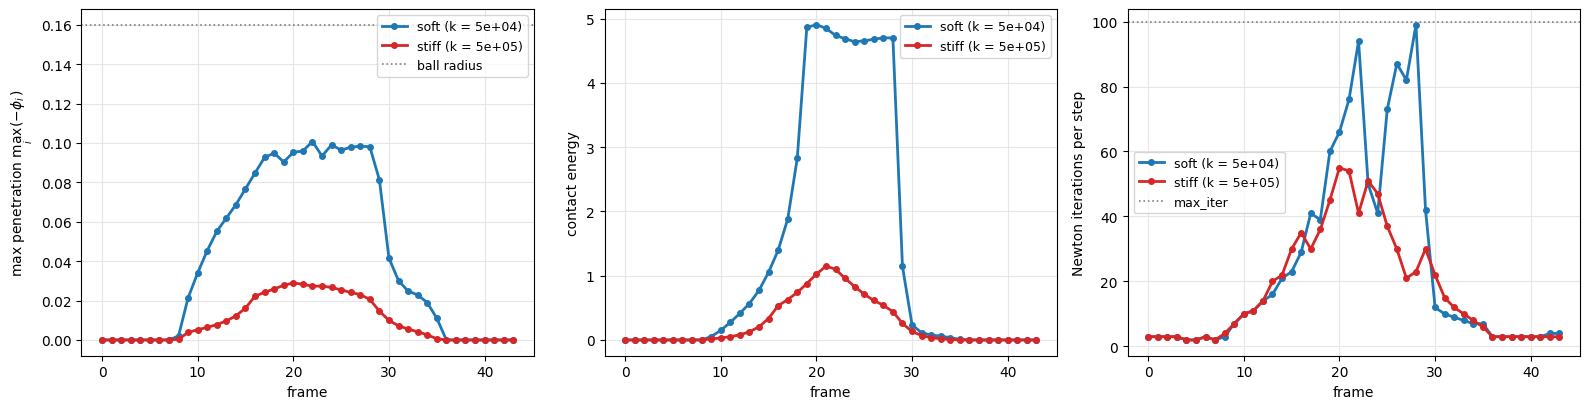

soft: contact-energy peak 4.91 at frame 20, 14 vertices inside the ball, mean depth 0.044
stiff: contact-energy peak 1.15 at frame 21, 11 vertices inside the ball, mean depth 0.009


In [13]:
frames = np.arange(len(ball_path))
labels = {"soft": f"soft (k = {K_CONTACT:.0e})", "stiff": f"stiff (k = {K_CONTACT_STIFF:.0e})"}
colors = {labels["soft"]: "#1f77b4", labels["stiff"]: "#d62728"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
panels = [("penetration", r"max penetration $\max_i(-\phi_i)$"),
          ("contact", "contact energy"),
          ("newton_iters", "Newton iterations per step")]
for ax, (key, ylabel) in zip(axes, panels):
    utils.line_plot(frames, {labels["soft"]: soft[key], labels["stiff"]: stiff[key]},
                    xlabel="frame", ylabel=ylabel, colors=colors, markers=True, ax=ax)
axes[0].axhline(BALL_R, color="0.5", ls=":", lw=1.2, label="ball radius")
axes[0].legend(fontsize=9)
axes[2].axhline(NEWTON_MAX_ITER, color="0.5", ls=":", lw=1.2, label="max_iter")
axes[2].legend(fontsize=9)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "soft_vs_stiff.png"),
                              copy_to=os.path.join(MEDIA_DIR, "008_soft_vs_stiff.png"))
plt.show()
for name, run in (("soft", soft), ("stiff", stiff)):
    kp = int(run["contact"].argmax())                         # frame of peak contact energy
    phi = np.linalg.norm(run["states"][kp] - run["centers"][kp], axis=1) - BALL_R
    print(f"{name}: contact-energy peak {run['contact'][kp]:.2f} at frame {kp}, "
          f"{int((phi < 0).sum())} vertices inside the ball, mean depth {-phi[phi < 0].mean():.3f}")

### Takeaways
* **Penalty contact** is an energy, $\tfrac{k}{2}\sum_i m_i \min(\phi_i,0)^2$, that switches on where the signed distance is negative; minimizing it pushes penetrating vertices back out, and it grows quadratically with depth.
* The **static probes** show the energy purely as a function of overlap; the **dynamic** runs let the block deform in response.
* **Contact stiffness is a knob**: too soft and the ball first dents the block, then pops through into it; 10&times; stiffer cuts penetration about 3.5&times; and dents the block instead.
* Contact is where Newton works hardest: the active set changes from step to step and the penalty has a kink in its second derivative, so steps in contact need many more iterations.